# PureJaxRL Usage Example

## Part 1: Installation and Setup

In [21]:
!pip install -r https://raw.githubusercontent.com/luchris429/purejaxrl/main/requirements.txt

## Part 2: Running Multiple Seeds

In [1]:
# Set the environment variable to specify which GPU to use
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Use GPU 1
#os.environ["XLA_FLAGS"] = "--xla_dump_to=/home/labcmap/daniil.tiapkin/f-regularised-policy-gradient/deeprl/xla_dump --xla_dump_hlo_pass_re=."  # Prevent JAX from preallocating all GPU memory

In [2]:
import jax
print(jax.default_backend())
print(jax.lib.xla_bridge.get_backend().platform)


gpu
gpu


/tmp/ipykernel_396645/1914323816.py:3: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  print(jax.lib.xla_bridge.get_backend().platform)


In [3]:
import jax
jax.devices()

[CudaDevice(id=0)]

In [4]:
config = {
    "LR": 5.0e-4,
    "LR_END": 5.0e-5,
    "NUM_ENVS": 16,
    "NUM_STEPS": 32,
    "TOTAL_TIMESTEPS": 1e6,
    "UPDATE_EPOCHS": 64,
    "NUM_MINIBATCHES": 4,
    "GAMMA": 0.99,
    "GAE_LAMBDA": 0.95,
    "CLIP_EPS": 0.2,
    "ENT_COEF": 0.003,
    "VF_COEF": 0.5,
    "MAX_GRAD_NORM": 0.5,
    "ACTIVATION": "tanh",
    "ENV_NAME": "DeepSea-bsuite",
    "ANNEAL_LR": True,
    "ALPHA_DIVERGENCE": 0.9,  # new parameter for alpha-divergence
    "ENV_SIZE": 8, 
}

#rng = jax.random.PRNGKey(42)
#train_jit = jax.jit(make_train(config))

#out = jax.block_until_ready(train_jit(rng))

## Original Code for PPO

In [5]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import numpy as np
import optax
from flax.linen.initializers import constant, orthogonal
from typing import Sequence, NamedTuple, Any
from flax.training.train_state import TrainState
import distrax
import gymnax
from gymnax.wrappers.purerl import FlattenObservationWrapper, LogWrapper

class ActorCritic(nn.Module):
    action_dim: Sequence[int]
    activation: str = "tanh"

    @nn.compact
    def __call__(self, x):
        if self.activation == "relu":
            activation = nn.relu
        else:
            activation = nn.tanh
        actor_mean = nn.Dense(
            64, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0)
        )(x)
        actor_mean = activation(actor_mean)
        actor_mean = nn.Dense(
            64, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0)
        )(actor_mean)
        actor_mean = activation(actor_mean)
        actor_mean = nn.Dense(
            self.action_dim, kernel_init=orthogonal(0.01), bias_init=constant(0.0)
        )(actor_mean)
        pi = distrax.Categorical(logits=actor_mean)

        critic = nn.Dense(
            64, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0)
        )(x)
        critic = activation(critic)
        critic = nn.Dense(
            64, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0)
        )(critic)
        critic = activation(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0))(
            critic
        )

        return pi, jnp.squeeze(critic, axis=-1)


class Transition(NamedTuple):
    done: jnp.ndarray
    action: jnp.ndarray
    value: jnp.ndarray
    reward: jnp.ndarray
    log_prob: jnp.ndarray
    obs: jnp.ndarray
    info: jnp.ndarray

def make_train(config):
    config["NUM_UPDATES"] = (
        config["TOTAL_TIMESTEPS"] // config["NUM_STEPS"] // config["NUM_ENVS"]
    )
    config["MINIBATCH_SIZE"] = (
        config["NUM_ENVS"] * config["NUM_STEPS"] // config["NUM_MINIBATCHES"]
    )
    env, env_params = gymnax.make(config["ENV_NAME"])
    env = FlattenObservationWrapper(env)
    env = LogWrapper(env)

    def linear_schedule(count):
        frac = 1.0 - (count // (config["NUM_MINIBATCHES"] * config["UPDATE_EPOCHS"])) / config["NUM_UPDATES"]
        return config["LR"] * frac

    def train(rng):

        # INIT NETWORK
        network = ActorCritic(env.action_space(env_params).n, activation=config["ACTIVATION"])
        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(env.observation_space(env_params).shape)
        network_params = network.init(_rng, init_x)
        if config["ANNEAL_LR"]:
            tx = optax.chain(
                optax.clip_by_global_norm(config["MAX_GRAD_NORM"]),
                optax.adam(learning_rate=linear_schedule, eps=1e-5),
            )
        else:
            tx = optax.chain(optax.clip_by_global_norm(config["MAX_GRAD_NORM"]), optax.adam(config["LR"], eps=1e-5))
        train_state = TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )

        # INIT ENV
        rng, _rng = jax.random.split(rng)
        reset_rng = jax.random.split(_rng, config["NUM_ENVS"])
        obsv, env_state = jax.vmap(env.reset, in_axes=(0, None))(reset_rng, env_params)

        # TRAIN LOOP
        def _update_step(runner_state, unused):
            # COLLECT TRAJECTORIES
            def _env_step(runner_state, unused):
                train_state, env_state, last_obs, rng = runner_state

                # SELECT ACTION
                rng, _rng = jax.random.split(rng)
                pi, value = network.apply(train_state.params, last_obs)
                action = pi.sample(seed=_rng)
                log_prob = pi.log_prob(action)

                # STEP ENV
                rng, _rng = jax.random.split(rng)
                rng_step = jax.random.split(_rng, config["NUM_ENVS"])
                obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                    rng_step, env_state, action, env_params
                )
                transition = Transition(
                    done, action, value, reward, log_prob, last_obs, info
                )
                runner_state = (train_state, env_state, obsv, rng)
                return runner_state, transition

            runner_state, traj_batch = jax.lax.scan(
                _env_step, runner_state, None, config["NUM_STEPS"]
            )

            # CALCULATE ADVANTAGE
            train_state, env_state, last_obs, rng = runner_state
            _, last_val = network.apply(train_state.params, last_obs)

            def _calculate_gae(traj_batch, last_val):
                def _get_advantages(gae_and_next_value, transition):
                    gae, next_value = gae_and_next_value
                    done, value, reward = (
                        transition.done,
                        transition.value,
                        transition.reward,
                    )
                    delta = reward + config["GAMMA"] * next_value * (1 - done) - value
                    gae = (
                        delta
                        + config["GAMMA"] * config["GAE_LAMBDA"] * (1 - done) * gae
                    )
                    return (gae, value), gae

                _, advantages = jax.lax.scan(
                    _get_advantages,
                    (jnp.zeros_like(last_val), last_val),
                    traj_batch,
                    reverse=True,
                    unroll=16,
                )
                return advantages, advantages + traj_batch.value

            advantages, targets = _calculate_gae(traj_batch, last_val)

            # UPDATE NETWORK
            def _update_epoch(update_state, unused):
                def _update_minbatch(train_state, batch_info):
                    traj_batch, advantages, targets = batch_info

                    def _loss_fn(params, traj_batch, gae, targets):
                        # RERUN NETWORK
                        pi, value = network.apply(params, traj_batch.obs)
                        log_prob = pi.log_prob(traj_batch.action)

                        # CALCULATE VALUE LOSS
                        value_pred_clipped = traj_batch.value + (
                            value - traj_batch.value
                        ).clip(-config["CLIP_EPS"], config["CLIP_EPS"])
                        value_losses = jnp.square(value - targets)
                        value_losses_clipped = jnp.square(value_pred_clipped - targets)
                        value_loss = (
                            0.5 * jnp.maximum(value_losses, value_losses_clipped).mean()
                        )

                        # CALCULATE ACTOR LOSS
                        ratio = jnp.exp(log_prob - traj_batch.log_prob)
                        gae = (gae - gae.mean()) / (gae.std() + 1e-8)
                        loss_actor1 = ratio * gae
                        loss_actor2 = (
                            jnp.clip(
                                ratio,
                                1.0 - config["CLIP_EPS"],
                                1.0 + config["CLIP_EPS"],
                            )
                            * gae
                        )
                        loss_actor = -jnp.minimum(loss_actor1, loss_actor2)
                        loss_actor = loss_actor.mean()
                        entropy = pi.entropy().mean()

                        total_loss = (
                            loss_actor
                            + config["VF_COEF"] * value_loss
                            - config["ENT_COEF"] * entropy
                        )
                        return total_loss, (value_loss, loss_actor, entropy)

                    grad_fn = jax.value_and_grad(_loss_fn, has_aux=True)
                    total_loss, grads = grad_fn(
                        train_state.params, traj_batch, advantages, targets
                    )
                    train_state = train_state.apply_gradients(grads=grads)
                    return train_state, total_loss

                train_state, traj_batch, advantages, targets, rng = update_state
                rng, _rng = jax.random.split(rng)
                batch_size = config["MINIBATCH_SIZE"] * config["NUM_MINIBATCHES"]
                assert (
                    batch_size == config["NUM_STEPS"] * config["NUM_ENVS"]
                ), "batch size must be equal to number of steps * number of envs"
                permutation = jax.random.permutation(_rng, batch_size)
                batch = (traj_batch, advantages, targets)
                batch = jax.tree_util.tree_map(
                    lambda x: x.reshape((batch_size,) + x.shape[2:]), batch
                )
                shuffled_batch = jax.tree_util.tree_map(
                    lambda x: jnp.take(x, permutation, axis=0), batch
                )
                minibatches = jax.tree_util.tree_map(
                    lambda x: jnp.reshape(
                        x, [config["NUM_MINIBATCHES"], -1] + list(x.shape[1:])
                    ),
                    shuffled_batch,
                )
                train_state, total_loss = jax.lax.scan(
                    _update_minbatch, train_state, minibatches
                )
                update_state = (train_state, traj_batch, advantages, targets, rng)
                return update_state, total_loss

            update_state = (train_state, traj_batch, advantages, targets, rng)
            update_state, loss_info = jax.lax.scan(
                _update_epoch, update_state, None, config["UPDATE_EPOCHS"]
            )
            train_state = update_state[0]
            metric = traj_batch.info
            rng = update_state[-1]

            runner_state = (train_state, env_state, last_obs, rng)
            return runner_state, metric

        rng, _rng = jax.random.split(rng)
        runner_state = (train_state, env_state, obsv, _rng)
        runner_state, metric = jax.lax.scan(
            _update_step, runner_state, None, config["NUM_UPDATES"]
        )
        return {"runner_state": runner_state, "metrics": metric}

    return train

In [ ]:
def make_train(config):
    config["NUM_UPDATES"] = (
        config["TOTAL_TIMESTEPS"] // config["NUM_STEPS"] // config["NUM_ENVS"]
    )
    config["MINIBATCH_SIZE"] = (
        config["NUM_ENVS"] * config["NUM_STEPS"] // config["NUM_MINIBATCHES"]
    )
    env, env_params = gymnax.make(
        config["ENV_NAME"],
        size=config["ENV_SIZE"],
    )
    env = FlattenObservationWrapper(env)
    env = LogWrapper(env)

    def linear_schedule(count):
        frac = 1.0 - (count // (config["NUM_MINIBATCHES"] * config["UPDATE_EPOCHS"])) / config["NUM_UPDATES"]
        return config["LR"] * frac

    def train(ent_coef, rng):

        # INIT NETWORK
        network = ActorCritic(env.action_space(env_params).n, activation=config["ACTIVATION"])
        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(env.observation_space(env_params).shape)
        network_params = network.init(_rng, init_x)
        if config["ANNEAL_LR"]:
            tx = optax.chain(
                optax.clip_by_global_norm(config["MAX_GRAD_NORM"]),
                optax.adam(learning_rate=linear_schedule, eps=1e-5),
            )
        else:
            tx = optax.chain(optax.clip_by_global_norm(config["MAX_GRAD_NORM"]), optax.adam(config["LR"], eps=1e-5))
        train_state = TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )

        # INIT ENV
        rng, _rng = jax.random.split(rng)
        reset_rng = jax.random.split(_rng, config["NUM_ENVS"])
        obsv, env_state = jax.vmap(env.reset, in_axes=(0, None))(reset_rng, env_params)

        # TRAIN LOOP
        def _update_step(runner_state, unused):
            # COLLECT TRAJECTORIES
            def _env_step(runner_state, unused):
                train_state, env_state, last_obs, rng = runner_state

                # SELECT ACTION
                rng, _rng = jax.random.split(rng)
                pi, value = network.apply(train_state.params, last_obs)
                action = pi.sample(seed=_rng)
                log_prob = pi.log_prob(action)

                # STEP ENV
                rng, _rng = jax.random.split(rng)
                rng_step = jax.random.split(_rng, config["NUM_ENVS"])
                obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                    rng_step, env_state, action, env_params
                )
                transition = Transition(
                    done, action, value, reward, log_prob, last_obs, info
                )
                runner_state = (train_state, env_state, obsv, rng)
                return runner_state, transition

            runner_state, traj_batch = jax.lax.scan(
                _env_step, runner_state, None, config["NUM_STEPS"]
            )

            # CALCULATE ADVANTAGE
            train_state, env_state, last_obs, rng = runner_state
            _, last_val = network.apply(train_state.params, last_obs)

            def _calculate_gae(traj_batch, last_val):
                def _get_advantages(gae_and_next_value, transition):
                    gae, next_value = gae_and_next_value
                    done, value, reward = (
                        transition.done,
                        transition.value,
                        transition.reward,
                    )
                    delta = reward + config["GAMMA"] * next_value * (1 - done) - value
                    gae = (
                        delta
                        + config["GAMMA"] * config["GAE_LAMBDA"] * (1 - done) * gae
                    )
                    return (gae, value), gae

                _, advantages = jax.lax.scan(
                    _get_advantages,
                    (jnp.zeros_like(last_val), last_val),
                    traj_batch,
                    reverse=True,
                    unroll=16,
                )
                return advantages, advantages + traj_batch.value

            advantages, targets = _calculate_gae(traj_batch, last_val)

            # UPDATE NETWORK
            def _update_epoch(update_state, unused):
                def _update_minbatch(train_state, batch_info):
                    traj_batch, advantages, targets = batch_info

                    def _loss_fn(params, traj_batch, gae, targets):
                        # RERUN NETWORK
                        pi, value = network.apply(params, traj_batch.obs)
                        log_prob = pi.log_prob(traj_batch.action)

                        # CALCULATE VALUE LOSS
                        value_pred_clipped = traj_batch.value + (
                            value - traj_batch.value
                        ).clip(-config["CLIP_EPS"], config["CLIP_EPS"])
                        value_losses = jnp.square(value - targets)
                        value_losses_clipped = jnp.square(value_pred_clipped - targets)
                        value_loss = (
                            0.5 * jnp.maximum(value_losses, value_losses_clipped).mean()
                        )

                        # CALCULATE ACTOR LOSS
                        ratio = jnp.exp(log_prob - traj_batch.log_prob)
                        gae = (gae - gae.mean()) / (gae.std() + 1e-8)
                        loss_actor1 = ratio * gae
                        loss_actor2 = (
                            jnp.clip(
                                ratio,
                                1.0 - config["CLIP_EPS"],
                                1.0 + config["CLIP_EPS"],
                            )
                            * gae
                        )
                        loss_actor = -jnp.minimum(loss_actor1, loss_actor2)
                        loss_actor = loss_actor.mean()
                        entropy = pi.entropy().mean()

                        total_loss = (
                            loss_actor
                            + config["VF_COEF"] * value_loss
                            - ent_coef * entropy
                        )
                        return total_loss, (value_loss, loss_actor, entropy)

                    grad_fn = jax.value_and_grad(_loss_fn, has_aux=True)
                    total_loss, grads = grad_fn(
                        train_state.params, traj_batch, advantages, targets
                    )
                    train_state = train_state.apply_gradients(grads=grads)
                    return train_state, total_loss

                train_state, traj_batch, advantages, targets, rng = update_state
                rng, _rng = jax.random.split(rng)
                batch_size = config["MINIBATCH_SIZE"] * config["NUM_MINIBATCHES"]
                assert (
                    batch_size == config["NUM_STEPS"] * config["NUM_ENVS"]
                ), "batch size must be equal to number of steps * number of envs"
                permutation = jax.random.permutation(_rng, batch_size)
                batch = (traj_batch, advantages, targets)
                batch = jax.tree_util.tree_map(
                    lambda x: x.reshape((batch_size,) + x.shape[2:]), batch
                )
                shuffled_batch = jax.tree_util.tree_map(
                    lambda x: jnp.take(x, permutation, axis=0), batch
                )
                minibatches = jax.tree_util.tree_map(
                    lambda x: jnp.reshape(
                        x, [config["NUM_MINIBATCHES"], -1] + list(x.shape[1:])
                    ),
                    shuffled_batch,
                )
                train_state, total_loss = jax.lax.scan(
                    _update_minbatch, train_state, minibatches
                )
                update_state = (train_state, traj_batch, advantages, targets, rng)
                return update_state, total_loss

            update_state = (train_state, traj_batch, advantages, targets, rng)
            update_state, loss_info = jax.lax.scan(
                _update_epoch, update_state, None, config["UPDATE_EPOCHS"]
            )
            train_state = update_state[0]
            metric = traj_batch.info
            rng = update_state[-1]

            runner_state = (train_state, env_state, last_obs, rng)
            return runner_state, metric

        rng, _rng = jax.random.split(rng)
        runner_state = (train_state, env_state, obsv, _rng)
        runner_state, metric = jax.lax.scan(
            _update_step, runner_state, None, config["NUM_UPDATES"]
        )
        return {"runner_state": runner_state, "metrics": metric}

    return train

In [ ]:
import time
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

ent_coef_search = jnp.array([0.0, 0.001, 0.0005, 0.01, 0.05, 0.1, 0.5])

N_seeds = 10
rng = jax.random.PRNGKey(42)
rngs = jax.random.split(rng, N_seeds)

# Outer vmap: over seeds
# Inner vmap: over ent_coef_search
train_vvjit = jax.jit(
    jax.vmap(
        jax.vmap(
            make_train(config), in_axes=(None, 0)
        ), in_axes=(0, None)
    )
)

t0 = time.time()
outs = jax.block_until_ready(train_vvjit(ent_coef_search,rngs))
print(f"time: {time.time() - t0:.2f} s")

# outs["metrics"]["returned_episode_returns"] has shape [N_seeds, len(ent_coef), ...]
for i in range(len(ent_coef_search)):
    mean_over_seeds = outs["metrics"]["returned_episode_returns"][:, i].mean(0).mean(-1).reshape(-1)
    plt.plot(mean_over_seeds, label=f"ent_coef={ent_coef_search[i]:.3f}")

plt.legend()
plt.xlabel("Update Step")
plt.ylabel("Average Return (over seeds)")
plt.show()


2025-11-11 14:20:55.243636: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


## Part 2: Coupled Parametrisation and Regularisation

In [5]:
config = {
    "LR": 5.0e-4,
    "LR_END": 5.0e-5,
    "NUM_ENVS": 16,
    "NUM_STEPS": 32,
    "TOTAL_TIMESTEPS": 1e6,
    "UPDATE_EPOCHS": 64,
    "NUM_MINIBATCHES": 4,
    "GAMMA": 0.99,
    "GAE_LAMBDA": 0.95,
    "CLIP_EPS": 0.2,
    "ENT_COEF": 0.003,
    "VF_COEF": 0.5,
    "MAX_GRAD_NORM": 0.5,
    "ACTIVATION": "tanh",
    "ENV_NAME": "DeepSea-bsuite",
    "ANNEAL_LR": True,
    "ALPHA_DIVERGENCE": 0.9,  # new parameter for alpha-divergence
    "ENV_SIZE": 4, 
}

In [6]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import numpy as np
import optax
from flax.linen.initializers import constant, orthogonal
from typing import Sequence, NamedTuple, Any
from flax.training.train_state import TrainState
import distrax
import gymnax
from gymnax.wrappers.purerl import FlattenObservationWrapper, LogWrapper

from functools import partial

from fdiv import AlphaDivergence

class ActorCritic(nn.Module):
    action_dim: Sequence[int]
    f_softargmax_fn: callable
    activation: str = "tanh"

    @nn.compact
    def __call__(self, x):
        if self.activation == "relu":
            activation = nn.relu
        else:
            activation = nn.tanh
        actor_mean = nn.Dense(
            64, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0)
        )(x)
        actor_mean = activation(actor_mean)
        actor_mean = nn.Dense(
            64, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0)
        )(actor_mean)
        actor_mean = activation(actor_mean)
        actor_mean = nn.Dense(
            self.action_dim, kernel_init=orthogonal(0.01), bias_init=constant(0.0)
        )(actor_mean)
        # Here we change the default divergence to alpha-divergence
        # log prob = log softargmax of the model outputs, that can be used as a usual logits
        logits = jnp.log(self.f_softargmax_fn(actor_mean))
        pi = distrax.Categorical(logits=logits)
        #probs = self.f_softargmax_fn(actor_mean)
        #probs = jnp.clip(probs, 1e-8, 1.0)  # avoid 0s
        #probs = jax.nn.softmax(actor_mean, axis=-1) 
        #pi = distrax.Categorical(probs=probs)
        critic = nn.Dense(
            64, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0)
        )(x)
        critic = activation(critic)
        critic = nn.Dense(
            64, kernel_init=orthogonal(np.sqrt(2)), bias_init=constant(0.0)
        )(critic)
        critic = activation(critic)
        critic = nn.Dense(1, kernel_init=orthogonal(1.0), bias_init=constant(0.0))(
            critic
        )

        return pi, jnp.squeeze(critic, axis=-1)


class Transition(NamedTuple):
    done: jnp.ndarray
    action: jnp.ndarray
    value: jnp.ndarray
    reward: jnp.ndarray
    log_prob: jnp.ndarray
    obs: jnp.ndarray
    info: jnp.ndarray

def make_train(config):
    config["NUM_UPDATES"] = (
        config["TOTAL_TIMESTEPS"] // config["NUM_STEPS"] // config["NUM_ENVS"]
    )
    print(f"num updates: {config['NUM_UPDATES']}")
    config["MINIBATCH_SIZE"] = (
        config["NUM_ENVS"] * config["NUM_STEPS"] // config["NUM_MINIBATCHES"]
    )
    env, env_params = gymnax.make(config["ENV_NAME"])
    env = FlattenObservationWrapper(env)
    env = LogWrapper(env)
    divergence = AlphaDivergence(alpha=config["ALPHA_DIVERGENCE"], use_implicit_diff=True)
    f_softargmax_fn = jax.jit(partial(divergence.softargmax, prior=None, beta=1.0))

    def linear_schedule(count):
        config["LR_END"] = config.get("LR_END", 0.0)
        frac = 1.0 - (count // (config["NUM_MINIBATCHES"] * config["UPDATE_EPOCHS"])) / config["NUM_UPDATES"]
        return config["LR"] * frac + (1.0 - frac) * config["LR_END"]

    def train(rng):

        # INIT NETWORK
        # Added here the alpha parameter for alpha-divergence
        network = ActorCritic(env.action_space(env_params).n, activation=config["ACTIVATION"], f_softargmax_fn=f_softargmax_fn)
        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(env.observation_space(env_params).shape)
        network_params = network.init(_rng, init_x)
        if config["ANNEAL_LR"]:
            tx = optax.chain(
                optax.clip_by_global_norm(config["MAX_GRAD_NORM"]),
                optax.adam(learning_rate=linear_schedule, eps=1e-5),
            )
        else:
            tx = optax.chain(optax.clip_by_global_norm(config["MAX_GRAD_NORM"]), optax.adam(config["LR"], eps=1e-5))
        train_state = TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )

        # INIT ENV
        rng, _rng = jax.random.split(rng)
        reset_rng = jax.random.split(_rng, config["NUM_ENVS"])
        obsv, env_state = jax.vmap(env.reset, in_axes=(0, None))(reset_rng, env_params)

        # TRAIN LOOP
        #@scan_tqdm(n=config["NUM_UPDATES"])
        def _update_step(runner_state, unused):
            # COLLECT TRAJECTORIES
            def _env_step(runner_state, unused):
                train_state, env_state, last_obs, rng = runner_state

                # SELECT ACTION
                rng, _rng = jax.random.split(rng)
                pi, value = network.apply(train_state.params, last_obs)
                action = pi.sample(seed=_rng)
                log_prob = pi.log_prob(action)

                # STEP ENV
                rng, _rng = jax.random.split(rng)
                rng_step = jax.random.split(_rng, config["NUM_ENVS"])
                obsv, env_state, reward, done, info = jax.vmap(env.step, in_axes=(0,0,0,None))(
                    rng_step, env_state, action, env_params
                )
                # TODO: add a corresonding f-divergence to reward function to regualize both actor and critic?
                transition = Transition(
                    done, action, value, reward, log_prob, last_obs, info
                )
                runner_state = (train_state, env_state, obsv, rng)
                return runner_state, transition

            runner_state, traj_batch = jax.lax.scan(
                _env_step, runner_state, None, config["NUM_STEPS"]
            )

            # CALCULATE ADVANTAGE
            train_state, env_state, last_obs, rng = runner_state
            _, last_val = network.apply(train_state.params, last_obs)

            def _calculate_gae(traj_batch, last_val):
                def _get_advantages(gae_and_next_value, transition):
                    gae, next_value = gae_and_next_value
                    done, value, reward = (
                        transition.done,
                        transition.value,
                        transition.reward,
                    )
                    delta = reward + config["GAMMA"] * next_value * (1 - done) - value
                    gae = (
                        delta
                        + config["GAMMA"] * config["GAE_LAMBDA"] * (1 - done) * gae
                    )
                    return (gae, value), gae

                _, advantages = jax.lax.scan(
                    _get_advantages,
                    (jnp.zeros_like(last_val), last_val),
                    traj_batch,
                    reverse=True,
                    unroll=16,
                )
                return advantages, advantages + traj_batch.value

            advantages, targets = _calculate_gae(traj_batch, last_val)

            # UPDATE NETWORK
            def _update_epoch(update_state, unused):
                def _update_minbatch(train_state, batch_info):
                    traj_batch, advantages, targets = batch_info

                    def _loss_fn(params, traj_batch, gae, targets):
                        # RERUN NETWORK
                        pi, value = network.apply(params, traj_batch.obs)
                        log_prob = pi.log_prob(traj_batch.action)

                        # CALCULATE VALUE LOSS
                        value_pred_clipped = traj_batch.value + (
                            value - traj_batch.value
                        ).clip(-config["CLIP_EPS"], config["CLIP_EPS"])
                        value_losses = jnp.square(value - targets)
                        value_losses_clipped = jnp.square(value_pred_clipped - targets)
                        value_loss = (
                            0.5 * jnp.maximum(value_losses, value_losses_clipped).mean()
                        )

                        # CALCULATE ACTOR LOSS
                        ratio = jnp.exp(log_prob - traj_batch.log_prob)
                        gae = (gae - gae.mean()) / (gae.std() + 1e-8)
                        loss_actor1 = ratio * gae
                        loss_actor2 = (
                            jnp.clip(
                                ratio,
                                1.0 - config["CLIP_EPS"],
                                1.0 + config["CLIP_EPS"],
                            )
                            * gae
                        )
                        loss_actor = -jnp.minimum(loss_actor1, loss_actor2)
                        loss_actor = loss_actor.mean()
                        entropy = pi.entropy().mean()

                        total_loss = (
                            loss_actor
                            + config["VF_COEF"] * value_loss
                            - config["ENT_COEF"] * entropy
                        )
                        return total_loss, (value_loss, loss_actor, entropy)

                    grad_fn = jax.value_and_grad(_loss_fn, has_aux=True)
                    total_loss, grads = grad_fn(
                        train_state.params, traj_batch, advantages, targets
                    )
                    train_state = train_state.apply_gradients(grads=grads)
                    return train_state, total_loss

                train_state, traj_batch, advantages, targets, rng = update_state
                rng, _rng = jax.random.split(rng)
                batch_size = config["MINIBATCH_SIZE"] * config["NUM_MINIBATCHES"]
                assert (
                    batch_size == config["NUM_STEPS"] * config["NUM_ENVS"]
                ), "batch size must be equal to number of steps * number of envs"
                permutation = jax.random.permutation(_rng, batch_size)
                batch = (traj_batch, advantages, targets)
                batch = jax.tree_util.tree_map(
                    lambda x: x.reshape((batch_size,) + x.shape[2:]), batch
                )
                shuffled_batch = jax.tree_util.tree_map(
                    lambda x: jnp.take(x, permutation, axis=0), batch
                )
                minibatches = jax.tree_util.tree_map(
                    lambda x: jnp.reshape(
                        x, [config["NUM_MINIBATCHES"], -1] + list(x.shape[1:])
                    ),
                    shuffled_batch,
                )
                train_state, total_loss = jax.lax.scan(
                    _update_minbatch, train_state, minibatches
                )
                update_state = (train_state, traj_batch, advantages, targets, rng)
                return update_state, total_loss

            update_state = (train_state, traj_batch, advantages, targets, rng)
            update_state, loss_info = jax.lax.scan(
                _update_epoch, update_state, None, config["UPDATE_EPOCHS"]
            )
            train_state = update_state[0]
            metric = traj_batch.info
            rng = update_state[-1]

            runner_state = (train_state, env_state, last_obs, rng)
            return runner_state, metric

        rng, _rng = jax.random.split(rng)
        runner_state = (train_state, env_state, obsv, _rng)
        runner_state, metric = jax.lax.scan(
            _update_step, runner_state, None, config["NUM_UPDATES"], unroll=False
        )
        return {"runner_state": runner_state, "metrics": metric}

    return train

In [7]:
def make_train(config):
    config["NUM_UPDATES"] = (
        config["TOTAL_TIMESTEPS"] // config["NUM_STEPS"] // config["NUM_ENVS"]
    )
    config["MINIBATCH_SIZE"] = (
        config["NUM_ENVS"] * config["NUM_STEPS"] // config["NUM_MINIBATCHES"]
    )

    env, env_params = gymnax.make(
        config["ENV_NAME"],
        size=config["ENV_SIZE"],
    )
    env = FlattenObservationWrapper(env)
    env = LogWrapper(env)

    divergence_constructor = partial(AlphaDivergence, use_implicit_diff=True)

    # base_lr is the hyperparameter we'll pass in
    def linear_schedule(base_lr, count):
        frac = 1.0 - (count // (config["NUM_MINIBATCHES"] * config["UPDATE_EPOCHS"])) / config["NUM_UPDATES"]
        return base_lr * frac

    # NOTE: now takes (alpha_coeff, entropy_coeff, lr, rng)
    def train(alpha_coeff, entropy_coeff, lr, rng):
        # INIT DIVERGENCE
        divergence = divergence_constructor(alpha=alpha_coeff)
        f_softargmax_fn = partial(divergence.softargmax, prior=None, beta=1.0)

        # INIT NETWORK
        network = ActorCritic(
            env.action_space(env_params).n,
            activation=config["ACTIVATION"],
            f_softargmax_fn=f_softargmax_fn,
        )
        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(env.observation_space(env_params).shape)
        network_params = network.init(_rng, init_x)

        # OPTIMIZER uses lr hyperparam
        if config["ANNEAL_LR"]:
            lr_schedule = lambda count: linear_schedule(lr, count)
            tx = optax.chain(
                optax.clip_by_global_norm(config["MAX_GRAD_NORM"]),
                optax.adam(learning_rate=lr_schedule, eps=1e-5),
            )
        else:
            tx = optax.chain(
                optax.clip_by_global_norm(config["MAX_GRAD_NORM"]),
                optax.adam(lr, eps=1e-5),
            )

        train_state = TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )

        # INIT ENV
        rng, _rng = jax.random.split(rng)
        reset_rng = jax.random.split(_rng, config["NUM_ENVS"])
        obsv, env_state = jax.vmap(env.reset, in_axes=(0, None))(reset_rng, env_params)

        # TRAIN LOOP
        def _update_step(runner_state, unused):
            # COLLECT TRAJECTORIES
            def _env_step(runner_state, unused):
                train_state, env_state, last_obs, rng = runner_state

                # SELECT ACTION
                rng, _rng = jax.random.split(rng)
                pi, value = network.apply(train_state.params, last_obs)
                action = pi.sample(seed=_rng)
                log_prob = pi.log_prob(action)

                # STEP ENV
                rng, _rng = jax.random.split(rng)
                rng_step = jax.random.split(_rng, config["NUM_ENVS"])
                obsv, env_state, reward, done, info = jax.vmap(
                    env.step, in_axes=(0, 0, 0, None)
                )(rng_step, env_state, action, env_params)
                transition = Transition(
                    done, action, value, reward, log_prob, last_obs, info
                )
                runner_state = (train_state, env_state, obsv, rng)
                return runner_state, transition

            runner_state, traj_batch = jax.lax.scan(
                _env_step, runner_state, None, config["NUM_STEPS"]
            )

            # CALCULATE ADVANTAGE
            train_state, env_state, last_obs, rng = runner_state
            _, last_val = network.apply(train_state.params, last_obs)

            def _calculate_gae(traj_batch, last_val):
                def _get_advantages(gae_and_next_value, transition):
                    gae, next_value = gae_and_next_value
                    done, value, reward = (
                        transition.done,
                        transition.value,
                        transition.reward,
                    )
                    delta = reward + config["GAMMA"] * next_value * (1 - done) - value
                    gae = (
                        delta
                        + config["GAMMA"] * config["GAE_LAMBDA"] * (1 - done) * gae
                    )
                    return (gae, value), gae

                _, advantages = jax.lax.scan(
                    _get_advantages,
                    (jnp.zeros_like(last_val), last_val),
                    traj_batch,
                    reverse=True,
                    unroll=16,
                )
                return advantages, advantages + traj_batch.value

            advantages, targets = _calculate_gae(traj_batch, last_val)

            # UPDATE NETWORK
            def _update_epoch(update_state, unused):
                def _update_minbatch(train_state, batch_info):
                    traj_batch, advantages, targets = batch_info

                    def _loss_fn(params, traj_batch, gae, targets):
                        # RERUN NETWORK
                        pi, value = network.apply(params, traj_batch.obs)
                        log_prob = pi.log_prob(traj_batch.action)


                        # VALUE LOSS
                        value_pred_clipped = traj_batch.value + (
                            value - traj_batch.value
                        ).clip(-config["CLIP_EPS"], config["CLIP_EPS"])
                        value_losses = jnp.square(value - targets)
                        value_losses_clipped = jnp.square(value_pred_clipped - targets)
                        value_loss = (
                            0.5 * jnp.maximum(value_losses, value_losses_clipped).mean()
                        )

                        # ACTOR LOSS
                        ratio = jnp.exp(log_prob - traj_batch.log_prob)
                        gae = (gae - gae.mean()) / (gae.std() + 1e-8)
                        loss_actor1 = ratio * gae
                        loss_actor2 = (
                            jnp.clip(
                                ratio,
                                1.0 - config["CLIP_EPS"],
                                1.0 + config["CLIP_EPS"],
                            )
                            * gae
                        )
                        loss_actor = -jnp.minimum(loss_actor1, loss_actor2).mean()

                        # ENTROPY TERM
                        '''
                        entropy = divergence.divergence(
                            p=pi.probs,
                            q=jnp.ones_like(pi.probs) / pi.probs.shape[-1],
                        ).mean()
                        '''
                        entropy = pi.entropy().mean()

                        # use entropy_coeff here (optionally scaled)
                        total_loss = (
                            loss_actor
                            + config["VF_COEF"] * value_loss
                            - entropy_coeff * entropy
                        )
                        return total_loss, (value_loss, loss_actor, entropy)

                    grad_fn = jax.value_and_grad(_loss_fn, has_aux=True)
                    (total_loss, aux), grads = grad_fn(
                        train_state.params, traj_batch, advantages, targets
                    )
                    train_state = train_state.apply_gradients(grads=grads)
                    return train_state, (total_loss, aux)

                train_state, traj_batch, advantages, targets, rng = update_state
                rng, _rng = jax.random.split(rng)
                batch_size = config["MINIBATCH_SIZE"] * config["NUM_MINIBATCHES"]
                assert (
                    batch_size == config["NUM_STEPS"] * config["NUM_ENVS"]
                ), "batch size must be equal to number of steps * number of envs"
                permutation = jax.random.permutation(_rng, batch_size)
                batch = (traj_batch, advantages, targets)
                batch = jax.tree_util.tree_map(
                    lambda x: x.reshape((batch_size,) + x.shape[2:]), batch
                )
                shuffled_batch = jax.tree_util.tree_map(
                    lambda x: jnp.take(x, permutation, axis=0), batch
                )
                minibatches = jax.tree_util.tree_map(
                    lambda x: jnp.reshape(
                        x, [config["NUM_MINIBATCHES"], -1] + list(x.shape[1:])
                    ),
                    shuffled_batch,
                )
                train_state, loss_info = jax.lax.scan(
                    _update_minbatch, train_state, minibatches
                )
                update_state = (train_state, traj_batch, advantages, targets, rng)
                return update_state, loss_info

            update_state = (train_state, traj_batch, advantages, targets, rng)
            update_state, loss_info = jax.lax.scan(
                _update_epoch, update_state, None, config["UPDATE_EPOCHS"]
            )
            train_state = update_state[0]
            metric = traj_batch.info
            rng = update_state[-1]

            runner_state = (train_state, env_state, last_obs, rng)
            return runner_state, metric

        rng, _rng = jax.random.split(rng)
        runner_state = (train_state, env_state, obsv, _rng)
        runner_state, metric = jax.lax.scan(
            _update_step, runner_state, None, config["NUM_UPDATES"]
        )
        return {"runner_state": runner_state, "metrics": metric}

    return train

In [8]:
import time
import matplotlib.pyplot as plt

In [9]:
#alpha_coef_search = jnp.array([0.01, 0.03, 0.1, 0.3, 0.5, 0.7, 0.9])
alpha_coef_search = jnp.array([1.0])
#lr_coef_search    = jnp.array([5e-4, 1e-3, 3e-4, 1e-4])
lr_coef_search    = jnp.array([1e-4])
entropy_coef_search = jnp.array([0.003, 0.01, 0.03, 0.1, 0.3, 0.5])

rng = jax.random.PRNGKey(42)
N_seeds = 10
rngs = jax.random.split(rng, N_seeds)  # [N_seeds, 2]

train_fn = make_train(config)

train_v4jit = jax.jit(
    jax.vmap(  # over alpha
        jax.vmap(  # over lr
            jax.vmap(  # over entropy
                jax.vmap(  # over seeds
                    train_fn,
                    in_axes=(None, None, None, 0),   # alpha, entropy, lr shared; rng mapped
                ),
                in_axes=(None, 0, None, None),       # entropy mapped; alpha & lr & rngs shared
            ),
            in_axes=(None, None, 0, None),           # lr mapped; alpha & entropy & rngs shared
        ),
        in_axes=(0, None, None, None),               # alpha mapped; others shared
    )
) # -> [N_alpha, N_entropy, N_seeds, ...]

t0 = time.time()
outs = jax.block_until_ready(
    train_v4jit(alpha_coef_search, entropy_coef_search, lr_coef_search, rngs)
)
print(f"time: {time.time() - t0:.2f} s")

IndexError: tuple index out of range

alpha=1.000 -> best lr=1.0e-04, best entropy=0.003, avg return=0.000


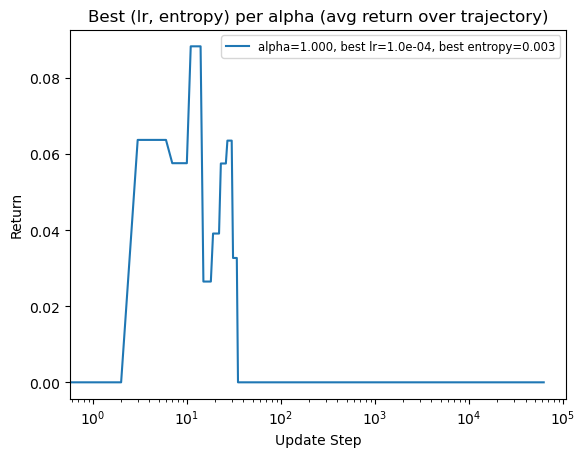

In [10]:
import numpy as np
import matplotlib.pyplot as plt

returns = outs["metrics"]["returned_episode_returns"]  # [N_alpha, N_lr, N_entropy, N_seeds, ...]

n_alpha   = len(alpha_coef_search)
n_lr      = len(lr_coef_search)
n_entropy = len(entropy_coef_search)

best_lr_indices      = []
best_entropy_indices = []

plt.figure()

for i in range(n_alpha):
    best_j = None  # best lr index
    best_k = None  # best entropy index
    best_score = -np.inf
    best_curve = None

    for j in range(n_lr):
        for k in range(n_entropy):
            # returns[i, j, k] has shape [N_seeds, ..., ...]
            # average over seeds and envs, keep curve over update steps
            curve = np.array(returns[i, j, k]).mean(0).mean(-1).reshape(-1)

            # score = average return over entire trajectory
            score = float(curve.mean())

            if score > best_score:
                best_score = score
                best_j = j
                best_k = k
                best_curve = curve

    best_lr_indices.append(best_j)
    best_entropy_indices.append(best_k)

    # Plot best curve for this alpha
    plt.plot(
        best_curve,
        label=(
            "alpha={:.3f}, best lr={:.1e}, best entropy={:.3f}"
            .format(
                float(alpha_coef_search[i]),
                float(lr_coef_search[best_j]),
                float(entropy_coef_search[best_k]),
            )
        ),
    )

    print(
        "alpha={:.3f} -> best lr={:.1e}, best entropy={:.3f}, avg return={:.3f}".format(
            float(alpha_coef_search[i]),
            float(lr_coef_search[best_j]),
            float(entropy_coef_search[best_k]),
            best_score,
        )
    )

plt.legend(fontsize="small")
plt.xscale("log")
# plt.yscale("log")  # optional
plt.xlabel("Update Step")
plt.ylabel("Return")
plt.title("Best (lr, entropy) per alpha (avg return over trajectory)")
plt.show()


Plotting all (lr, entropy) curves for alpha=1.000


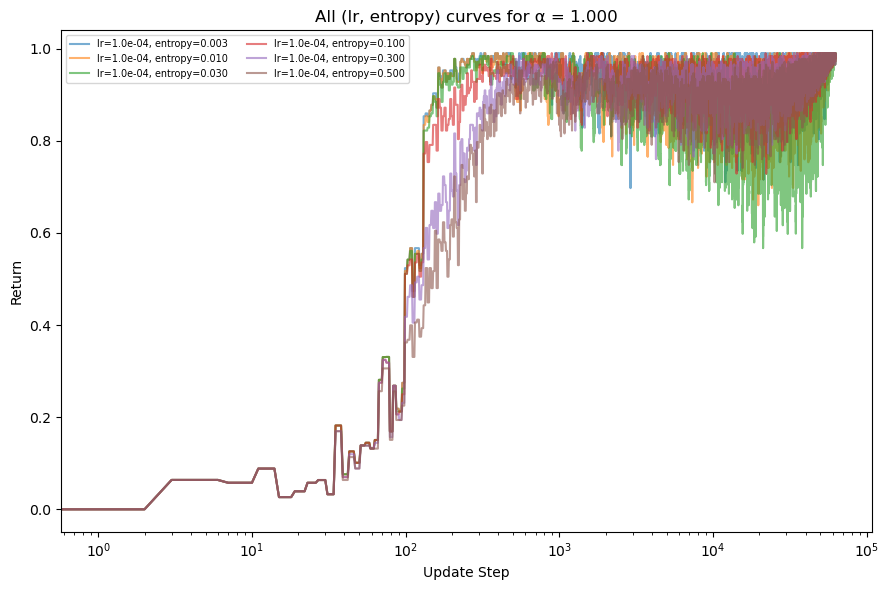

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# shape: [N_alpha, N_lr, N_entropy, N_seeds, ...]
returns = np.array(outs["metrics"]["returned_episode_returns"])

n_alpha   = len(alpha_coef_search)
n_lr      = len(lr_coef_search)
n_entropy = len(entropy_coef_search)

# Find the index corresponding to alpha = 1.0
alpha_target = 1.0
i_alpha = np.argmin(np.abs(np.array(alpha_coef_search) - alpha_target))

print(f"Plotting all (lr, entropy) curves for alpha={alpha_coef_search[i_alpha]:.3f}")

plt.figure(figsize=(9, 6))

for j in range(n_lr):
    for k in range(n_entropy):
        # average over seeds and environments, keep trajectory over update steps
        curve = returns[i_alpha, j, k].mean(0).mean(-1).reshape(-1)

        plt.plot(
            curve,
            alpha=0.6,
            label=f"lr={lr_coef_search[j]:.1e}, entropy={entropy_coef_search[k]:.3f}"
        )

plt.xscale("log")
plt.xlabel("Update Step")
plt.ylabel("Return")
plt.title(f"All (lr, entropy) curves for α = {alpha_coef_search[i_alpha]:.3f}")
plt.legend(fontsize="x-small", ncol=2)
plt.tight_layout()
plt.show()


## Part 3: Decoupled Parametrization and Regularisation

In [6]:
def make_train(config):
    config["NUM_UPDATES"] = (
        config["TOTAL_TIMESTEPS"] // config["NUM_STEPS"] // config["NUM_ENVS"]
    )
    config["MINIBATCH_SIZE"] = (
        config["NUM_ENVS"] * config["NUM_STEPS"] // config["NUM_MINIBATCHES"]
    )

    env, env_params = gymnax.make(
        config["ENV_NAME"],
        size=config["ENV_SIZE"],
    )
    env = FlattenObservationWrapper(env)
    env = LogWrapper(env)

    divergence_constructor = partial(AlphaDivergence, use_implicit_diff=True)

    # base_lr is the hyperparameter we'll pass in
    def linear_schedule(base_lr, count):
        frac = 1.0 - (count // (config["NUM_MINIBATCHES"] * config["UPDATE_EPOCHS"])) / config["NUM_UPDATES"]
        return base_lr * frac

    # NOTE: now takes (alpha_coeff, entropy_coeff, lr, rng)
    def train(alpha_coeff, entropy_coeff, lr, rng):
        # INIT DIVERGENCE
        divergence = divergence_constructor(alpha=alpha_coeff)
        f_softargmax_fn = partial(divergence.softargmax, prior=None, beta=1.0)

        # INIT NETWORK
        network = ActorCritic(
            env.action_space(env_params).n,
            activation=config["ACTIVATION"],
            f_softargmax_fn=f_softargmax_fn,
        )
        rng, _rng = jax.random.split(rng)
        init_x = jnp.zeros(env.observation_space(env_params).shape)
        network_params = network.init(_rng, init_x)

        # OPTIMIZER uses lr hyperparam
        if config["ANNEAL_LR"]:
            lr_schedule = lambda count: linear_schedule(lr, count)
            tx = optax.chain(
                optax.clip_by_global_norm(config["MAX_GRAD_NORM"]),
                optax.adam(learning_rate=lr_schedule, eps=1e-5),
            )
        else:
            tx = optax.chain(
                optax.clip_by_global_norm(config["MAX_GRAD_NORM"]),
                optax.adam(lr, eps=1e-5),
            )

        train_state = TrainState.create(
            apply_fn=network.apply,
            params=network_params,
            tx=tx,
        )

        # INIT ENV
        rng, _rng = jax.random.split(rng)
        reset_rng = jax.random.split(_rng, config["NUM_ENVS"])
        obsv, env_state = jax.vmap(env.reset, in_axes=(0, None))(reset_rng, env_params)

        # TRAIN LOOP
        def _update_step(runner_state, unused):
            # COLLECT TRAJECTORIES
            def _env_step(runner_state, unused):
                train_state, env_state, last_obs, rng = runner_state

                # SELECT ACTION
                rng, _rng = jax.random.split(rng)
                pi, value = network.apply(train_state.params, last_obs)
                action = pi.sample(seed=_rng)
                log_prob = pi.log_prob(action)

                # STEP ENV
                rng, _rng = jax.random.split(rng)
                rng_step = jax.random.split(_rng, config["NUM_ENVS"])
                obsv, env_state, reward, done, info = jax.vmap(
                    env.step, in_axes=(0, 0, 0, None)
                )(rng_step, env_state, action, env_params)
                transition = Transition(
                    done, action, value, reward, log_prob, last_obs, info
                )
                runner_state = (train_state, env_state, obsv, rng)
                return runner_state, transition

            runner_state, traj_batch = jax.lax.scan(
                _env_step, runner_state, None, config["NUM_STEPS"]
            )

            # CALCULATE ADVANTAGE
            train_state, env_state, last_obs, rng = runner_state
            _, last_val = network.apply(train_state.params, last_obs)

            def _calculate_gae(traj_batch, last_val):
                def _get_advantages(gae_and_next_value, transition):
                    gae, next_value = gae_and_next_value
                    done, value, reward = (
                        transition.done,
                        transition.value,
                        transition.reward,
                    )
                    delta = reward + config["GAMMA"] * next_value * (1 - done) - value
                    gae = (
                        delta
                        + config["GAMMA"] * config["GAE_LAMBDA"] * (1 - done) * gae
                    )
                    return (gae, value), gae

                _, advantages = jax.lax.scan(
                    _get_advantages,
                    (jnp.zeros_like(last_val), last_val),
                    traj_batch,
                    reverse=True,
                    unroll=16,
                )
                return advantages, advantages + traj_batch.value

            advantages, targets = _calculate_gae(traj_batch, last_val)

            # UPDATE NETWORK
            def _update_epoch(update_state, unused):
                def _update_minbatch(train_state, batch_info):
                    traj_batch, advantages, targets = batch_info

                    def _loss_fn(params, traj_batch, gae, targets):
                        # RERUN NETWORK
                        pi, value = network.apply(params, traj_batch.obs)
                        log_prob = pi.log_prob(traj_batch.action)

                        # VALUE LOSS
                        value_pred_clipped = traj_batch.value + (
                            value - traj_batch.value
                        ).clip(-config["CLIP_EPS"], config["CLIP_EPS"])
                        value_losses = jnp.square(value - targets)
                        value_losses_clipped = jnp.square(value_pred_clipped - targets)
                        value_loss = (
                            0.5 * jnp.maximum(value_losses, value_losses_clipped).mean()
                        )

                        # ACTOR LOSS
                        ratio = jnp.exp(log_prob - traj_batch.log_prob)
                        gae = (gae - gae.mean()) / (gae.std() + 1e-8)
                        loss_actor1 = ratio * gae
                        loss_actor2 = (
                            jnp.clip(
                                ratio,
                                1.0 - config["CLIP_EPS"],
                                1.0 + config["CLIP_EPS"],
                            )
                            * gae
                        )
                        loss_actor = -jnp.minimum(loss_actor1, loss_actor2).mean()

                        # ENTROPY TERM
                        entropy = divergence.divergence(
                            p=pi.probs,
                            q=jnp.ones_like(pi.probs) / pi.probs.shape[-1],
                        ).mean()

                        # use entropy_coeff here (optionally scaled)
                        total_loss = (
                            loss_actor
                            + config["VF_COEF"] * value_loss
                            - entropy_coeff * entropy
                        )
                        return total_loss, (value_loss, loss_actor, entropy)

                    grad_fn = jax.value_and_grad(_loss_fn, has_aux=True)
                    (total_loss, aux), grads = grad_fn(
                        train_state.params, traj_batch, advantages, targets
                    )
                    train_state = train_state.apply_gradients(grads=grads)
                    return train_state, (total_loss, aux)

                train_state, traj_batch, advantages, targets, rng = update_state
                rng, _rng = jax.random.split(rng)
                batch_size = config["MINIBATCH_SIZE"] * config["NUM_MINIBATCHES"]
                assert (
                    batch_size == config["NUM_STEPS"] * config["NUM_ENVS"]
                ), "batch size must be equal to number of steps * number of envs"
                permutation = jax.random.permutation(_rng, batch_size)
                batch = (traj_batch, advantages, targets)
                batch = jax.tree_util.tree_map(
                    lambda x: x.reshape((batch_size,) + x.shape[2:]), batch
                )
                shuffled_batch = jax.tree_util.tree_map(
                    lambda x: jnp.take(x, permutation, axis=0), batch
                )
                minibatches = jax.tree_util.tree_map(
                    lambda x: jnp.reshape(
                        x, [config["NUM_MINIBATCHES"], -1] + list(x.shape[1:])
                    ),
                    shuffled_batch,
                )
                train_state, loss_info = jax.lax.scan(
                    _update_minbatch, train_state, minibatches
                )
                update_state = (train_state, traj_batch, advantages, targets, rng)
                return update_state, loss_info

            update_state = (train_state, traj_batch, advantages, targets, rng)
            update_state, loss_info = jax.lax.scan(
                _update_epoch, update_state, None, config["UPDATE_EPOCHS"]
            )
            train_state = update_state[0]
            metric = traj_batch.info
            rng = update_state[-1]

            runner_state = (train_state, env_state, last_obs, rng)
            return runner_state, metric

        rng, _rng = jax.random.split(rng)
        runner_state = (train_state, env_state, obsv, _rng)
        runner_state, metric = jax.lax.scan(
            _update_step, runner_state, None, config["NUM_UPDATES"]
        )
        return {"runner_state": runner_state, "metrics": metric}

    return train


Now, We can `vmap` across different values for the entropy coefficient and also `vmap` across different values for the `rngs`!

This means we call `vmap` twice to evaluate the different entropy coefficient on the same set of seeds.

In [7]:
import time
import matplotlib.pyplot as plt

In [10]:
alpha_coef_search = jnp.array([0.01, 0.03, 0.1, 0.3, 0.5, 0.7, 0.9])
lr_coef_search    = jnp.array([5e-4, 1e-3, 3e-4, 1e-4])
entropy_coef_search = jnp.array([0.003, 0.01, 0.03, 0.1, 0.3, 0.5])

rng = jax.random.PRNGKey(42)
N_seeds = 10
rngs = jax.random.split(rng, N_seeds)  # [N_seeds, 2]

train_fn = make_train(config)

train_v4jit = jax.jit(
    jax.vmap(  # over alpha
        jax.vmap(  # over lr
            jax.vmap(  # over entropy
                jax.vmap(  # over seeds
                    train_fn,
                    in_axes=(None, None, None, 0),   # alpha, entropy, lr shared; rng mapped
                ),
                in_axes=(None, 0, None, None),       # entropy mapped; alpha & lr & rngs shared
            ),
            in_axes=(None, None, 0, None),           # lr mapped; alpha & entropy & rngs shared
        ),
        in_axes=(0, None, None, None),               # alpha mapped; others shared
    )
) # -> [N_alpha, N_entropy, N_seeds, ...]

t0 = time.time()
outs = jax.block_until_ready(
    train_v4jit(alpha_coef_search, entropy_coef_search, lr_coef_search, rngs)
)
print(f"time: {time.time() - t0:.2f} s")



TypeError: Argument 'Traced<float32[]>with<BatchTrace> with
  val = Traced<float32[7]>with<DynamicJaxprTrace>
  batch_dim = 0' of type <class 'jax._src.interpreters.batching.BatchTracer'> is not a valid JAX type.

alpha=0.010 -> best lr=1.0e-04, best entropy=0.100, avg return=0.983
alpha=0.030 -> best lr=1.0e-04, best entropy=0.100, avg return=0.983
alpha=0.100 -> best lr=1.0e-04, best entropy=0.100, avg return=0.984
alpha=0.300 -> best lr=1.0e-04, best entropy=0.100, avg return=0.986
alpha=0.500 -> best lr=1.0e-04, best entropy=0.100, avg return=0.987
alpha=0.700 -> best lr=1.0e-04, best entropy=0.100, avg return=0.987
alpha=0.900 -> best lr=1.0e-04, best entropy=0.300, avg return=0.988


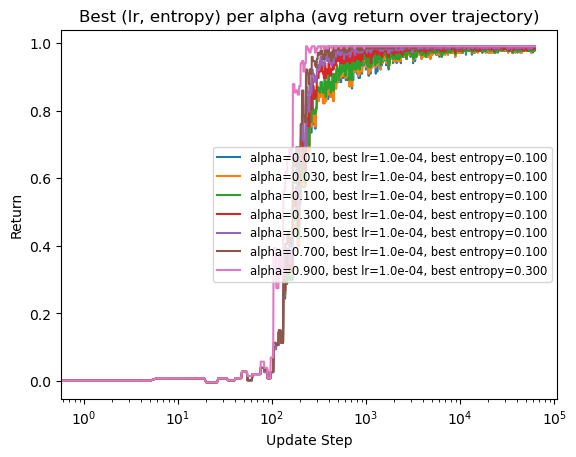

In [39]:
import numpy as np
import matplotlib.pyplot as plt

returns = outs["metrics"]["returned_episode_returns"]  # [N_alpha, N_lr, N_entropy, N_seeds, ...]

n_alpha   = len(alpha_coef_search)
n_lr      = len(lr_coef_search)
n_entropy = len(entropy_coef_search)

best_lr_indices      = []
best_entropy_indices = []

plt.figure()

for i in range(n_alpha):
    best_j = None  # best lr index
    best_k = None  # best entropy index
    best_score = -np.inf
    best_curve = None

    for j in range(n_lr):
        for k in range(n_entropy):
            # returns[i, j, k] has shape [N_seeds, ..., ...]
            # average over seeds and envs, keep curve over update steps
            curve = np.array(returns[i, j, k]).mean(0).mean(-1).reshape(-1)

            # score = average return over entire trajectory
            score = float(curve.mean())

            if score > best_score:
                best_score = score
                best_j = j
                best_k = k
                best_curve = curve

    best_lr_indices.append(best_j)
    best_entropy_indices.append(best_k)

    # Plot best curve for this alpha
    plt.plot(
        best_curve,
        label=(
            "alpha={:.3f}, best lr={:.1e}, best entropy={:.3f}"
            .format(
                float(alpha_coef_search[i]),
                float(lr_coef_search[best_j]),
                float(entropy_coef_search[best_k]),
            )
        ),
    )

    print(
        "alpha={:.3f} -> best lr={:.1e}, best entropy={:.3f}, avg return={:.3f}".format(
            float(alpha_coef_search[i]),
            float(lr_coef_search[best_j]),
            float(entropy_coef_search[best_k]),
            best_score,
        )
    )

plt.legend(fontsize="small")
plt.xscale("log")
# plt.yscale("log")  # optional
plt.xlabel("Update Step")
plt.ylabel("Return")
plt.title("Best (lr, entropy) per alpha (avg return over trajectory)")
plt.show()

